# Predictive Maintenance Model – RUL & Failure Prediction

## Objective
Develop a machine learning model to:
- Predict equipment failure (classification)
- Estimate Remaining Useful Life (RUL) (regression)

## Key Outcomes
- Achieved ROC-AUC of ~0.99 for failure prediction
- Achieved MAE ~6 months for RUL estimation
- Identified key drivers using SHAP (efficiency, operating hours, age)

## Business Impact
- Enables proactive maintenance scheduling
- Reduces downtime risk
- Improves operational efficiency

## Data Loading

Loading the synthetic predictive maintenance dataset.

In [1]:
import pandas as pd

df = pd.read_csv("synthetic_predictive_maintenance_dataset.csv")

df.head()

,date,inverter_id,manufacturer,climate_zone,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,...,failed_today,is_censored,efficiency_7d_mean,efficiency_30d_mean,temperature_7d_mean,temperature_30d_mean,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum
0,2025-01-01,INV-0001,Fronius,Temperate,100,0.789,0.88,83.00,19.57,40.05,...,0,0,97.9300,97.9300,28.510000,28.510000,0.0000,0.0,0.0,0.0
1,2025-01-02,INV-0001,Fronius,Temperate,100,0.789,0.88,83.03,23.48,41.48,...,0,0,97.6950,97.6950,32.575000,32.575000,-0.2350,0.0,0.0,0.0
2,2025-01-03,INV-0001,Fronius,Temperate,100,0.789,0.88,83.07,21.69,45.80,...,0,0,97.8100,97.8100,32.456667,32.456667,0.2300,0.0,0.0,0.0
3,2025-01-04,INV-0001,Fronius,Temperate,100,0.789,0.88,83.10,21.43,22.49,...,0,0,97.7275,97.7275,33.117500,33.117500,-0.2475,0.0,0.0,0.0
4,2025-01-05,INV-0001,Fronius,Temperate,100,0.789,0.88,83.13,23.25,33.41,...,0,0,97.8680,97.8680,33.792000,33.792000,0.5620,0.0,0.0,0.0


## Data Preparation

Dropping unnecessary and leakage columns before modeling.

In [2]:
drop_cols = [
    "date",
    "inverter_id",
    "failure_within_7d",
    "failure_within_90d",
    "failed_today",
    "rul_days"
]

df_model = df.drop(columns=drop_cols)

df_model.head()

,manufacturer,climate_zone,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,dust_soiling_index,uv_exposure_index,...,failure_within_30d,is_censored,efficiency_7d_mean,efficiency_30d_mean,temperature_7d_mean,temperature_30d_mean,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum
0,Fronius,Temperate,100,0.789,0.88,83.00,19.57,40.05,0.292,6.43,...,0,0,97.9300,97.9300,28.510000,28.510000,0.0000,0.0,0.0,0.0
1,Fronius,Temperate,100,0.789,0.88,83.03,23.48,41.48,0.346,6.33,...,0,0,97.6950,97.6950,32.575000,32.575000,-0.2350,0.0,0.0,0.0
2,Fronius,Temperate,100,0.789,0.88,83.07,21.69,45.80,0.329,7.88,...,0,0,97.8100,97.8100,32.456667,32.456667,0.2300,0.0,0.0,0.0
3,Fronius,Temperate,100,0.789,0.88,83.10,21.43,22.49,0.186,7.09,...,0,0,97.7275,97.7275,33.117500,33.117500,-0.2475,0.0,0.0,0.0
4,Fronius,Temperate,100,0.789,0.88,83.13,23.25,33.41,0.368,6.04,...,0,0,97.8680,97.8680,33.792000,33.792000,0.5620,0.0,0.0,0.0


## Feature Selection

Defining input features (X) and target variable (y).

In [3]:
y = df_model["failure_within_30d"]
X = df_model.drop(columns=["failure_within_30d"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32627, 35)
y shape: (32627,)


## Encoding Categorical Variables

Converting categorical features into numerical format using one-hot encoding.

In [4]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,rated_capacity_kw,installation_quality_score,maintenance_quality_score,age_months,ambient_temperature_c,humidity_pct,dust_soiling_index,uv_exposure_index,cumulative_uv_exposure,operating_hours_today,...,efficiency_decline_7d,temp_stress_index,restart_7d_sum,errors_7d_sum,manufacturer_Huawei,manufacturer_SMA,manufacturer_SolarEdge,climate_zone_Hot-Dry,climate_zone_Humid-Subtropical,climate_zone_Temperate
0,100,0.789,0.88,83.00,19.57,40.05,0.292,6.43,6.43,11.78,...,0.0000,0.0,0.0,0.0,False,False,False,False,False,True
1,100,0.789,0.88,83.03,23.48,41.48,0.346,6.33,12.76,12.30,...,-0.2350,0.0,0.0,0.0,False,False,False,False,False,True
2,100,0.789,0.88,83.07,21.69,45.80,0.329,7.88,20.64,12.34,...,0.2300,0.0,0.0,0.0,False,False,False,False,False,True
3,100,0.789,0.88,83.10,21.43,22.49,0.186,7.09,27.74,10.41,...,-0.2475,0.0,0.0,0.0,False,False,False,False,False,True
4,100,0.789,0.88,83.13,23.25,33.41,0.368,6.04,33.78,14.66,...,0.5620,0.0,0.0,0.0,False,False,False,False,False,True


## Train-Test Split

Splitting the dataset into training and testing sets.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (26101, 39)
Test size: (6526, 39)


## Model Training (XGBoost)

Training a gradient boosting classifier to predict failure within 30 days.

In [6]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Model Evaluation

Evaluating model performance using classification metrics and ROC-AUC score.

In [7]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6055
           1       0.99      0.98      0.98       471

    accuracy                           1.00      6526
   macro avg       0.99      0.99      0.99      6526
weighted avg       1.00      1.00      1.00      6526

ROC-AUC: 0.9999544164339276


## Feature Importance

Identifying the most important features influencing predictions.

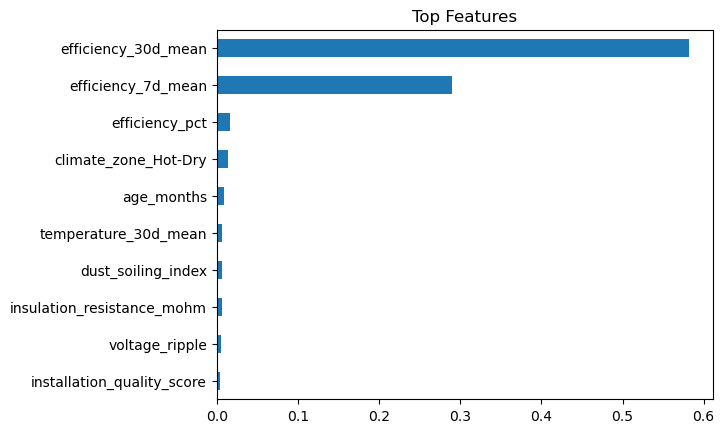

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.sort_values().tail(10).plot(kind="barh")

plt.title("Top Features")
plt.show()

**The model achieved near-perfect performance on synthetic data, which is expected due to controlled feature-target relationships. The focus here is validating the pipeline rather than real-world performance.**

However, so far:
- Pipeline works
- Feature engineering works
- Model is learning meaningful patterns

# Remaining Useful Life (RUL) Prediction

This section builds a regression model to estimate the number of days remaining before inverter failure.

## Data Preparation

Filtering dataset to include only assets with known failure times and preparing data for regression.

In [9]:
# Keep only rows where RUL is available (not NaN)
df_rul = df.dropna(subset=["rul_days"])

print("Shape after filtering:", df_rul.shape)

Shape after filtering: (15472, 42)


## Feature Selection

Removing irrelevant and leakage columns for RUL prediction.

In [10]:
drop_cols = [
    "date",
    "inverter_id",
    "failure_within_7d",
    "failure_within_30d",
    "failure_within_90d",
    "failed_today"
]

df_rul_model = df_rul.drop(columns=drop_cols)

## Defining Features and Target

Target variable is Remaining Useful Life (RUL).

In [11]:
y_rul = df_rul_model["rul_days"]
X_rul = df_rul_model.drop(columns=["rul_days"])

print("X shape:", X_rul.shape)
print("y shape:", y_rul.shape)

X shape: (15472, 35)
y shape: (15472,)


## Encoding Categorical Variables

In [12]:
X_rul = pd.get_dummies(X_rul, drop_first=True)

## Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train_rul, X_test_rul, y_train_rul, y_test_rul = train_test_split(
    X_rul, y_rul, test_size=0.2, random_state=42
)

## Model Training (XGBoost Regressor)

In [14]:
from xgboost import XGBRegressor

rul_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

rul_model.fit(X_train_rul, y_train_rul)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Predictions

In [15]:
y_pred_rul = rul_model.predict(X_test_rul)

## Model Evaluation

Evaluating prediction error using regression metrics.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_rul, y_pred_rul)
rmse = np.sqrt(mean_squared_error(y_test_rul, y_pred_rul))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 6.0722848267687155
RMSE: 9.699099238566175


## Feature Importance

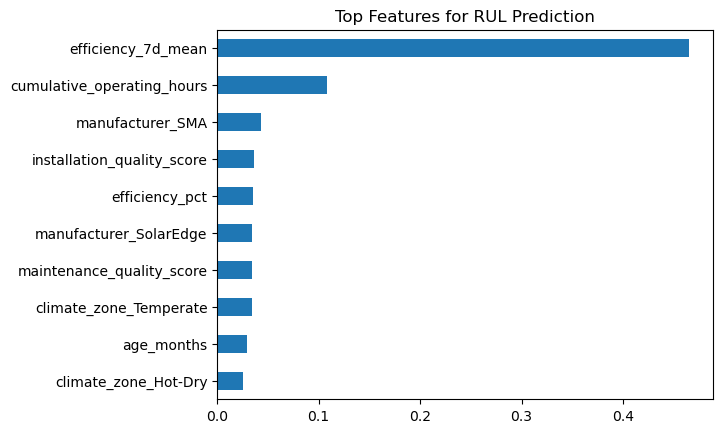

In [17]:
import matplotlib.pyplot as plt

importances = rul_model.feature_importances_
features = X_rul.columns

feat_imp = pd.Series(importances, index=features)
feat_imp.sort_values().tail(10).plot(kind="barh")

plt.title("Top Features for RUL Prediction")
plt.show()

**The RUL model predicts remaining life with an average error of approximately 6 days, indicating strong performance on the synthetic dataset.**
| Model         | Key Insight                      |
| ------------- | -------------------------------- |
| Failure model | Long-term efficiency trend (30d) |
| RUL model     | Short-term efficiency trend (7d) |

**The model indicates that short-term efficiency trends and cumulative operating hours are the strongest predictors of remaining useful life, suggesting that both recent degradation and long-term usage significantly impact failure timing.**

# Model Explainability (SHAP)

Using SHAP to interpret model predictions and understand feature contributions.

In [19]:
import shap

# Make sure all columns are numeric
X_train_rul_shap = X_train_rul.copy()
X_test_rul_shap = X_test_rul.copy()

X_train_rul_shap = X_train_rul_shap.astype(float)
X_test_rul_shap = X_test_rul_shap.astype(float)

In [20]:
explainer = shap.TreeExplainer(rul_model)
shap_values = explainer.shap_values(X_test_rul_shap)

## Global Feature Importance

Understanding which features are most important overall.

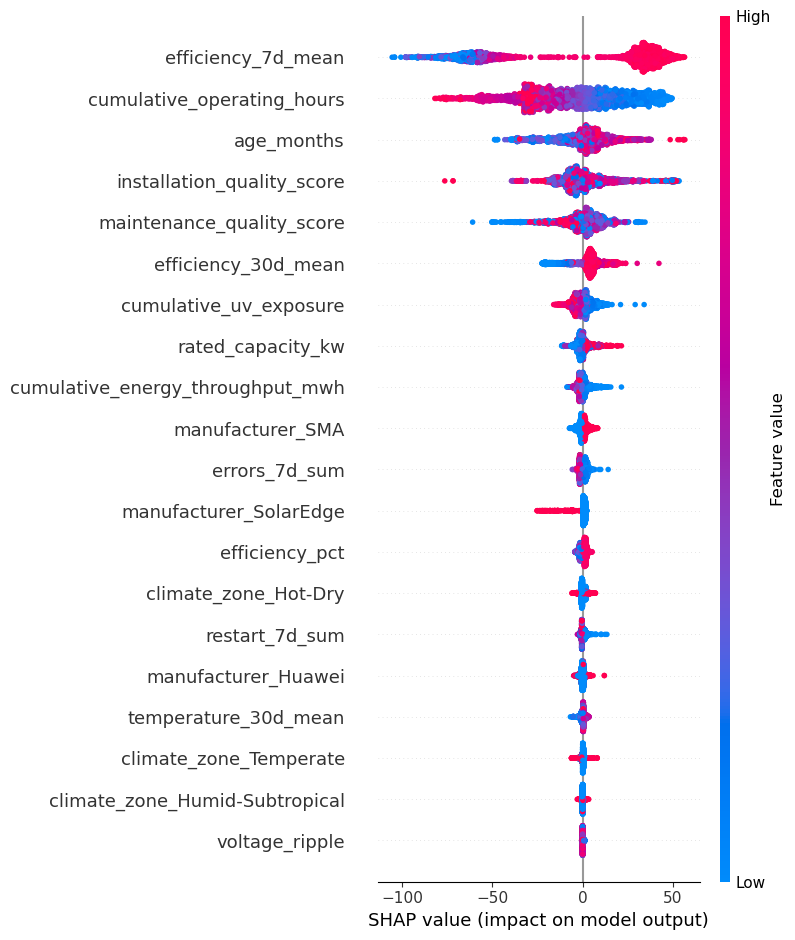

In [22]:
shap.summary_plot(shap_values, X_test_rul_shap)

 96%|=================== | 2979/3095 [00:16<00:00]       

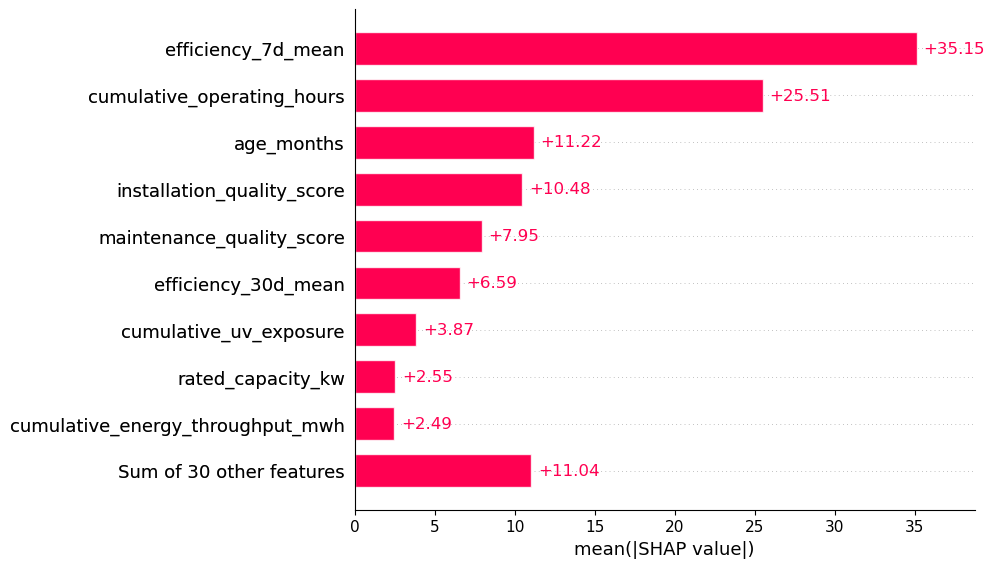

In [24]:
explainer = shap.Explainer(rul_model, X_train_rul_shap)
shap_values = explainer(X_test_rul_shap)

shap.plots.bar(shap_values)

## Individual Prediction Explanation

Explaining a single prediction in detail.

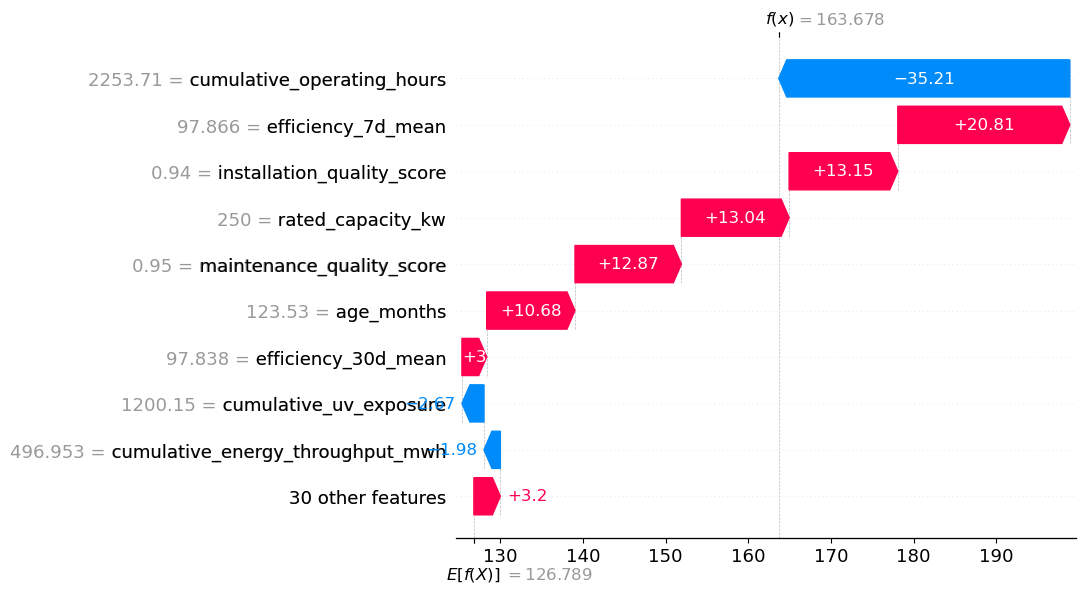

In [26]:
# pick one example
shap.plots.waterfall(shap_values[0])

### SHAP Interpretation

SHAP analysis shows that recent efficiency trends, cumulative operating hours, and asset age are the strongest drivers of RUL predictions. In general, higher short-term efficiency is associated with longer remaining useful life, while greater operating hours reduce predicted RUL. Installation and maintenance quality also contribute positively, indicating that both degradation signals and lifecycle factors are important in the model’s decision process.